In [2]:
%reset -f
%pip install openpyxl

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans

In [4]:
df = pd.read_excel("weather_data.xlsx", header = 3)
#print(df.head())
#print(df.info())
df2 = df.dropna(subset = ['soil_temperature_6cm (°C)'])

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

In [6]:
print(df[num_cols].describe().T)

                                 count          mean           std      min  \
temperature_2m (°C)             1872.0      0.630662      4.598747   -9.700   
relative_humidity_2m (%)        1872.0     83.086538     10.794321   43.000   
dew_point_2m (°C)               1872.0     -1.981464      5.536478  -15.900   
apparent_temperature (°C)       1872.0     -3.203739      5.453098  -15.000   
precipitation_probability (%)   1872.0     11.345620     24.616735    0.000   
precipitation (mm)              1872.0      0.040064      0.178531    0.000   
rain (mm)                       1872.0      0.027404      0.154401    0.000   
pressure_msl (hPa)              1872.0   1012.692201     11.100636  978.400   
cloud_cover (%)                 1872.0     77.803419     36.485002    0.000   
visibility (m)                  1872.0  22581.752137  17598.783312   80.000   
temperature_80m (°C)            1872.0     -0.032212      4.815591  -10.600   
wind_speed_10m (km/h)           1872.0     10.791827

In [7]:
corr_matrix = df.corr()
corr_matrix.to_excel("correlation_matrix.xlsx")

In [8]:
x = df["relative_humidity_2m (%)"]
y = df["visibility (m)"]


r =  0.1676779334340763
p =  2.840183438248566e-13


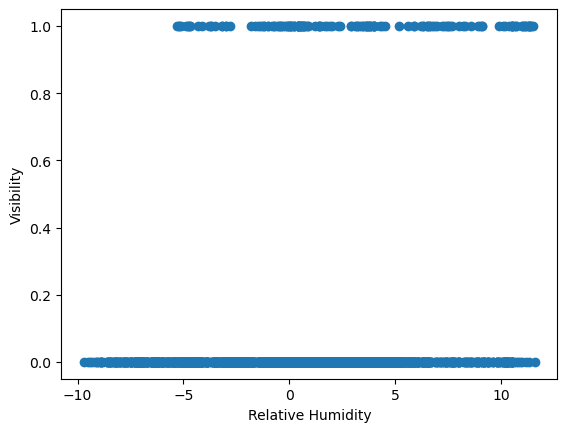

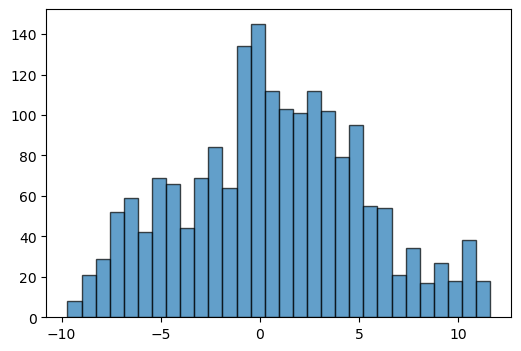

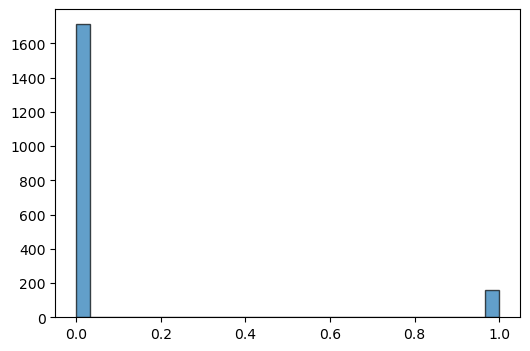

In [36]:
r, p_value = stats.pearsonr(x,y)
print("r = ", r)
print("p = ", p_value)

plt.figure()
plt.scatter(x,y)
plt.xlabel("Relative Humidity")
plt.ylabel("Visibility")
plt.show()

variables = x, y
for var in variables:
    plt.figure(figsize=(6,4))
    plt.hist(var, bins=30, edgecolor='black', alpha=0.7)
    plt.show()

In [10]:
rho, p_value = stats.spearmanr(x,y)
print(rho)
print(p_value)

-0.8914008085480458
0.0


In [18]:
#create rain event variable (for logistic regression)
df['rain_event'] = (df['precipitation (mm)'] > 0).astype(int)
rain = df[df['rain_event'] == 1]
no_rain = df[df['rain_event'] == 0]

In [53]:
variables = ["temperature_2m (°C)", "relative_humidity_2m (%)", "dew_point_2m (°C)", 
             "pressure_msl (hPa)", "cloud_cover (%)", "wind_speed_10m (km/h)"]
comparison = pd.DataFrame({
    'Rain Mean': rain[variables].mean(),
    'No Rain Mean': no_rain[variables].mean(),
    'Difference': rain[variables].mean() - no_rain[variables].mean()
})
print(comparison)

results = []
for var in variables:
    stat, p = stats.ttest_ind(rain[var].dropna(),
                        no_rain[var].dropna(),
                        equal_var=False)
    results.append({
        'Variable': var,
        't-stat': stat,
        'p-value': p
    })
ttest_results = pd.DataFrame(results)
print(ttest_results)

                            Rain Mean  No Rain Mean  Difference
temperature_2m (°C)          3.161006      0.395797    2.765209
relative_humidity_2m (%)    89.981132     82.446585    7.534547
dew_point_2m (°C)            1.661006     -2.319556    3.980563
pressure_msl (hPa)        1001.947170   1013.689550  -11.742381
cloud_cover (%)             99.125786     75.824285   23.301501
wind_speed_10m (km/h)       12.349686     10.647227    1.702458
                   Variable     t-stat        p-value
0       temperature_2m (°C)   7.005311   4.431611e-11
1  relative_humidity_2m (%)  13.549629   5.019134e-32
2         dew_point_2m (°C)   9.360099   2.082343e-17
3        pressure_msl (hPa) -12.482891   2.688273e-26
4           cloud_cover (%)  24.799461  1.424802e-117
5     wind_speed_10m (km/h)   4.018108   8.682076e-05


In [43]:
X = df[variables]
y = df['rain_event']

X = sm.add_constant(X)
model = sm.Logit(y,X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.195872
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:             rain_event   No. Observations:                 1872
Model:                          Logit   Df Residuals:                     1865
Method:                           MLE   Df Model:                            6
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.3261
Time:                        10:30:06   Log-Likelihood:                -366.67
converged:                       True   LL-Null:                       -544.12
Covariance Type:            nonrobust   LLR p-value:                 1.373e-73
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       96.8598     24.676      3.925      0.000      48.49

In [44]:
X = df[['pressure_msl (hPa)','cloud_cover (%)','wind_speed_10m (km/h)']]
y = df['rain_event']

X = sm.add_constant(X)
model = sm.Logit(y,X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.233087
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:             rain_event   No. Observations:                 1872
Model:                          Logit   Df Residuals:                     1868
Method:                           MLE   Df Model:                            3
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.1981
Time:                        10:30:39   Log-Likelihood:                -436.34
converged:                       True   LL-Null:                       -544.12
Covariance Type:            nonrobust   LLR p-value:                 1.827e-46
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    61.2993      8.657      7.081      0.000      44.332      78

Confustion matrix:
 [[338   5]
 [ 25   7]]
Accuracy: 0.92
AUC: 0.8446610787172012


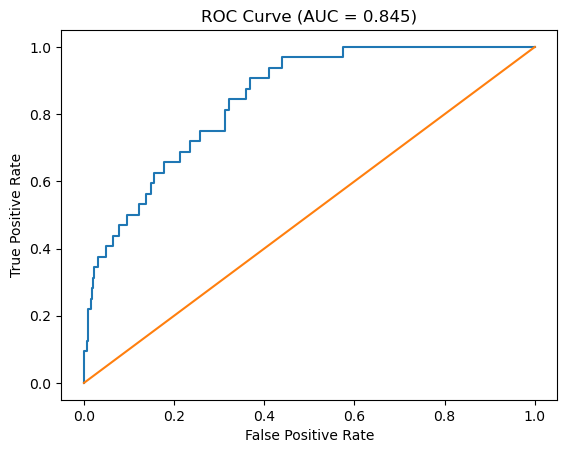

In [57]:
X = df[variables]
y = df['rain_event']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0, stratify=y)
log_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

p= log_model.predict_proba(X_test)[:,1]
yhat = (p >= 0.5).astype(int)

print("Confustion matrix:\n", confusion_matrix(y_test, yhat))
print("Accuracy:", accuracy_score(y_test, yhat))
print("AUC:", roc_auc_score(y_test,p))

p = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, p)
auc = roc_auc_score(y_test, p)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

Confustion matrix:
 [[343   0]
 [ 31   1]]
Accuracy: 0.9173333333333333
AUC: 0.7825255102040816


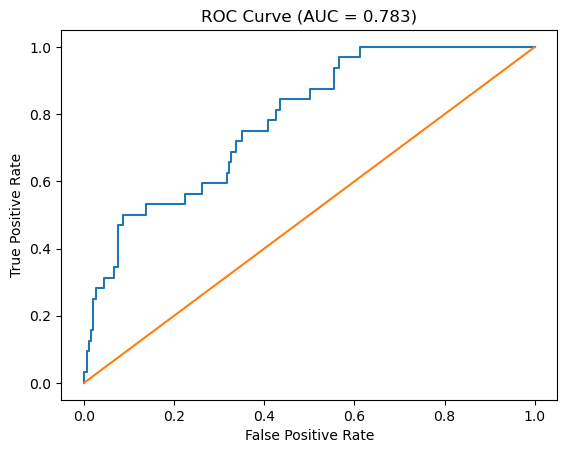

In [58]:
X = df[['pressure_msl (hPa)','cloud_cover (%)','wind_speed_10m (km/h)']]
y = df['rain_event']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0, stratify=y)
log_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

p= log_model.predict_proba(X_test)[:,1]
yhat = (p >= 0.5).astype(int)

print("Confustion matrix:\n", confusion_matrix(y_test, yhat))
print("Accuracy:", accuracy_score(y_test, yhat))
print("AUC:", roc_auc_score(y_test,p))

p = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, p)
auc = roc_auc_score(y_test, p)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

Confustion matrix:
 [[342   1]
 [ 31   1]]
Accuracy: 0.9146666666666666
AUC: 0.7873086734693877


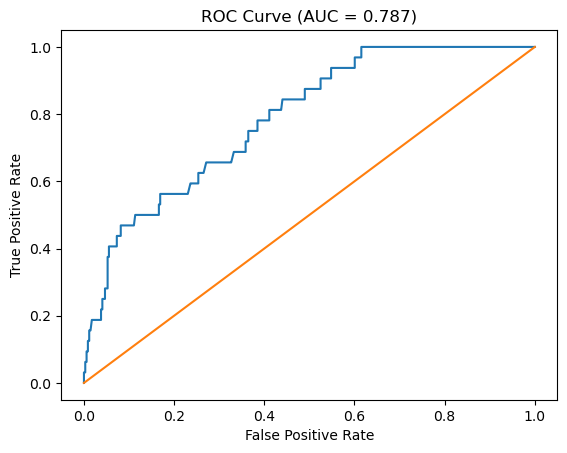

In [59]:
X = df[['pressure_msl (hPa)','cloud_cover (%)']]
y = df['rain_event']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=0, stratify=y)
log_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

p= log_model.predict_proba(X_test)[:,1]
yhat = (p >= 0.5).astype(int)

print("Confustion matrix:\n", confusion_matrix(y_test, yhat))
print("Accuracy:", accuracy_score(y_test, yhat))
print("AUC:", roc_auc_score(y_test,p))

p = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, p)
auc = roc_auc_score(y_test, p)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()